In [ ]:
# Install required libraries
!pip install mlxtend scikit-learn pandas matplotlib seaborn numpy -q
print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [ ]:
from google.colab import files
import io
import pandas as pd

print("📤 Please upload your CSV dataset file...")
uploaded = files.upload()

# Load the uploaded file
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\n✅ File '{filename}' uploaded successfully!")
print(f"📊 Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n🔍 First 5 rows:")
df.head()

📤 Please upload your CSV dataset file...


Saving StudentPerformancePrediction.csv to StudentPerformancePrediction.csv

✅ File 'StudentPerformancePrediction.csv' uploaded successfully!
📊 Dataset shape: 480 rows × 17 columns

🔍 First 5 rows:


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.rcParams['figure.facecolor'] = '#f8f9fa'
sns.set_palette('Set2')

print("=" * 60)
print("        📊 DATASET INFORMATION")
print("=" * 60)
print(f"Total Students   : {df.shape[0]}")
print(f"Total Features   : {df.shape[1]}")
print(f"\nColumn Names     : {list(df.columns)}")
print(f"\nMissing Values   :\n{df.isnull().sum()}")
print(f"\nData Types       :\n{df.dtypes}")
print("\n📈 Statistical Summary:")
df.describe()

        📊 DATASET INFORMATION
Total Students   : 480
Total Features   : 17

Column Names     : ['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class']

Missing Values   :
gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

Data Types       :
gender                      object
NationalITy                 object
PlaceofB

,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333
std,30.779223,33.080007,26.611244,27.637735
min,0.000000,0.000000,0.000000,1.000000
25%,15.750000,20.000000,14.000000,20.000000
50%,50.000000,65.000000,33.000000,39.000000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


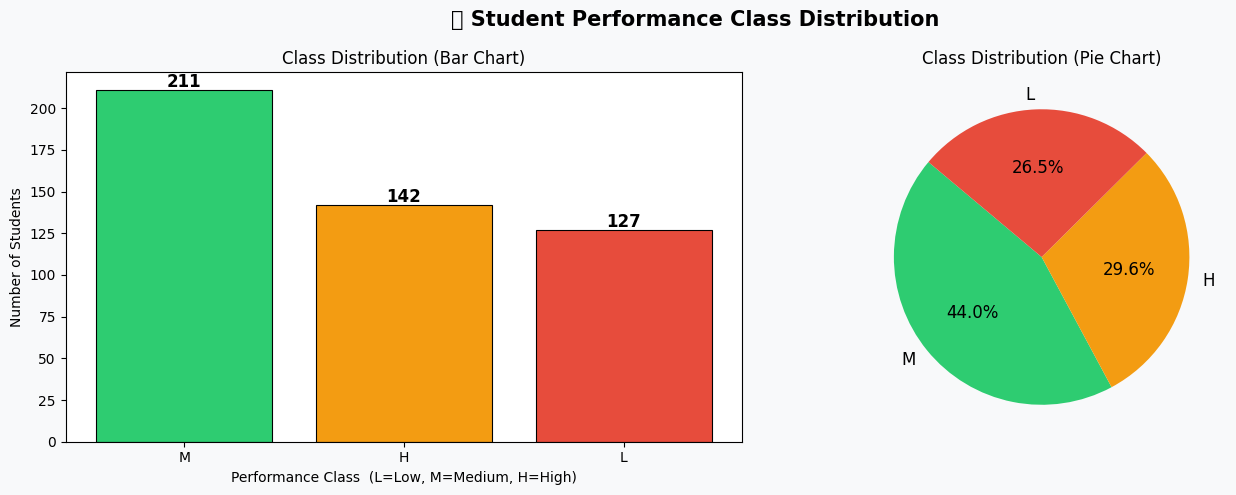

✅ Graph 1 saved: Class Distribution


In [ ]:
# ── Graph 1: Class Distribution (Target Variable)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🎯 Student Performance Class Distribution', fontsize=15, fontweight='bold')

class_counts = df['Class'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']

# Bar chart
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=12)
axes[0].set_xlabel('Performance Class  (L=Low, M=Medium, H=High)')
axes[0].set_ylabel('Number of Students')
for i, (cls, cnt) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, cnt + 2, str(cnt), ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=12)

plt.tight_layout()
plt.savefig('graph1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 1 saved: Class Distribution")

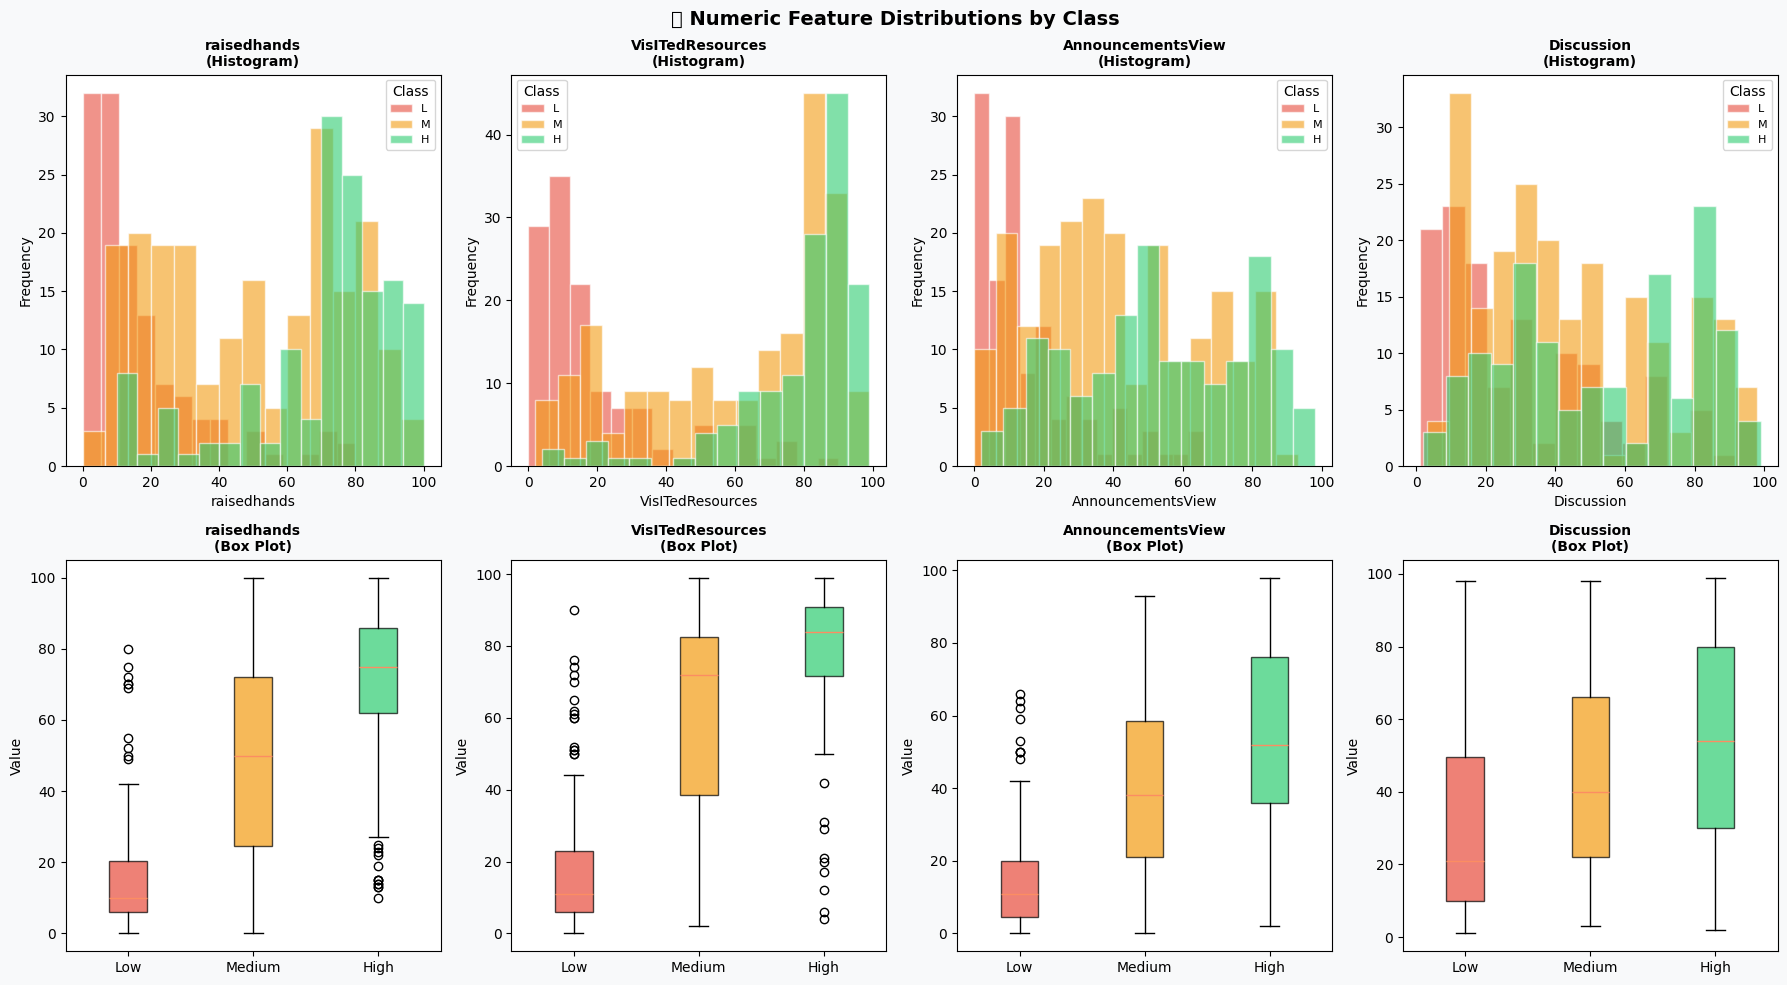

✅ Graph 2 saved: Feature Distributions


In [ ]:
# ── Graph 2: Feature Distributions
numeric_cols = ['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('📊 Numeric Feature Distributions by Class', fontsize=14, fontweight='bold')

class_colors = {'L': '#e74c3c', 'M': '#f39c12', 'H': '#2ecc71'}

for i, col in enumerate(numeric_cols):
    # Histogram
    ax1 = axes[0][i]
    for cls in ['L', 'M', 'H']:
        subset = df[df['Class'] == cls][col]
        ax1.hist(subset, bins=15, alpha=0.6, color=class_colors[cls], label=cls, edgecolor='white')
    ax1.set_title(f'{col}\n(Histogram)', fontsize=10, fontweight='bold')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Frequency')
    ax1.legend(title='Class', fontsize=8)

    # Box plot
    ax2 = axes[1][i]
    data_by_class = [df[df['Class'] == cls][col].values for cls in ['L', 'M', 'H']]
    bp = ax2.boxplot(data_by_class, labels=['Low', 'Medium', 'High'], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#e74c3c', '#f39c12', '#2ecc71']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_title(f'{col}\n(Box Plot)', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Value')

plt.tight_layout()
plt.savefig('graph2_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 2 saved: Feature Distributions")

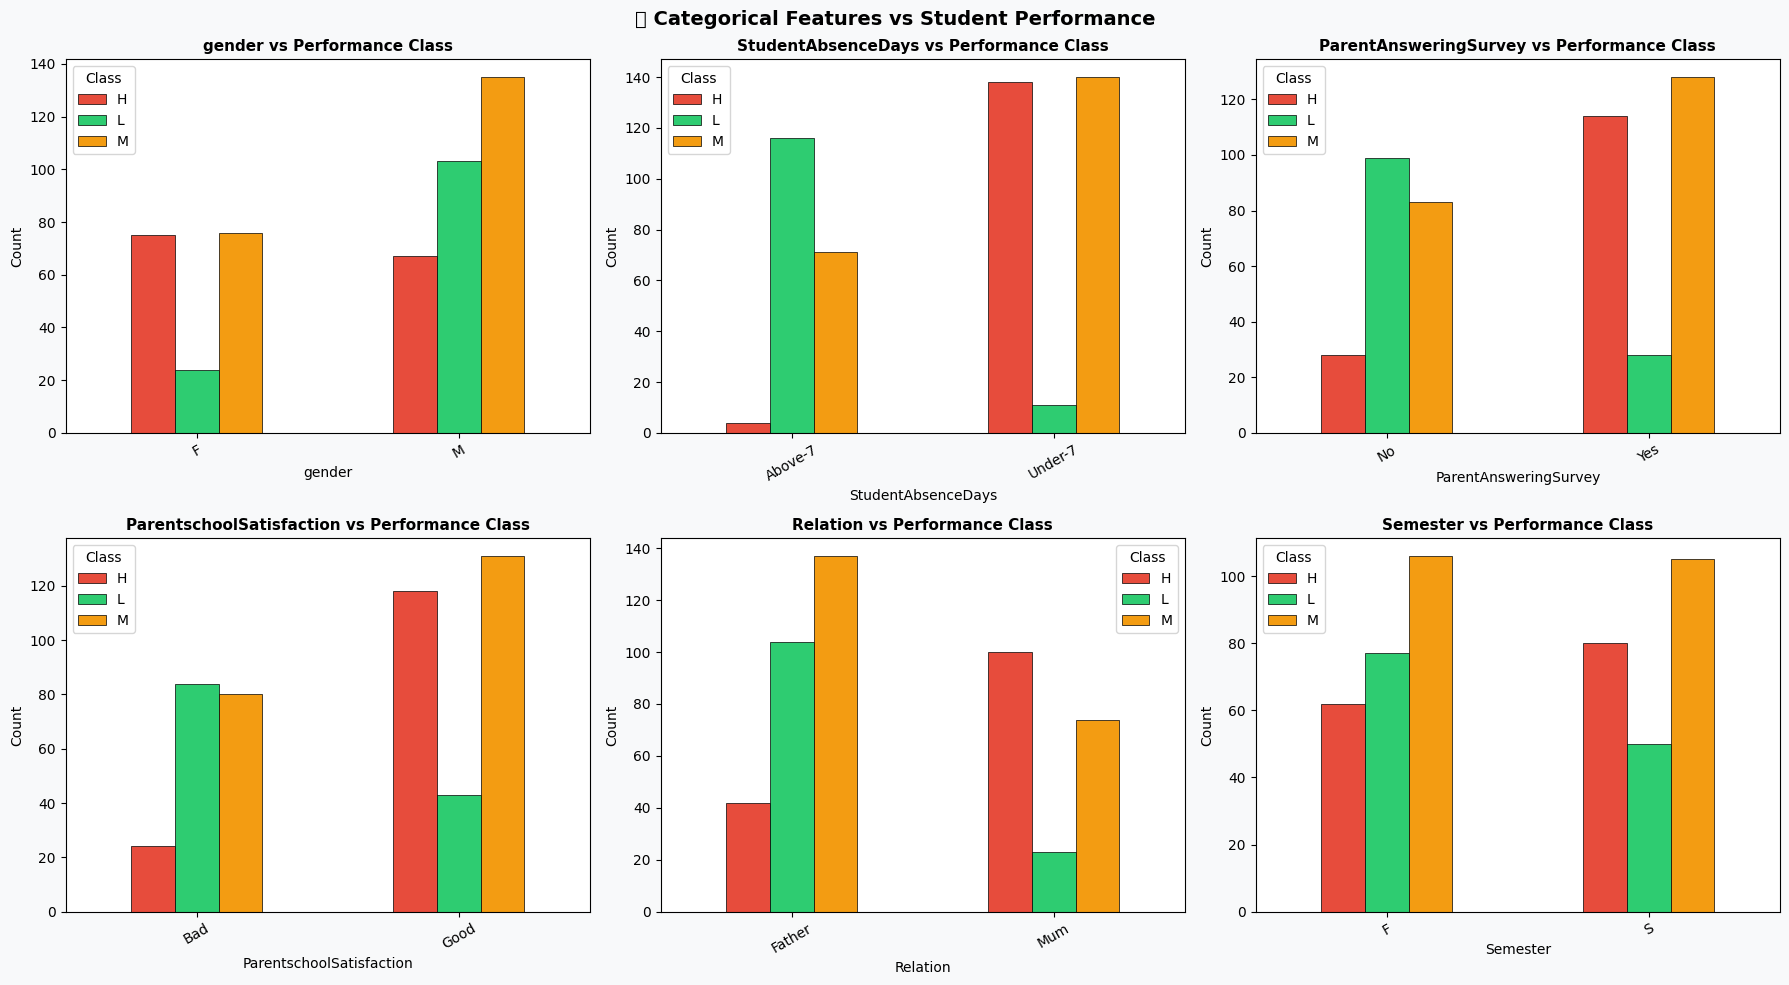

✅ Graph 3 saved: Categorical Analysis


In [ ]:
# ── Graph 3: Categorical Features Analysis
cat_cols = ['gender', 'StudentAbsenceDays', 'ParentAnsweringSurvey',
            'ParentschoolSatisfaction', 'Relation', 'Semester']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📋 Categorical Features vs Student Performance', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    cross = pd.crosstab(df[col], df['Class'])
    cross.plot(kind='bar', ax=axes[i], color=['#e74c3c', '#2ecc71', '#f39c12'],
               edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{col} vs Performance Class', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Class')

plt.tight_layout()
plt.savefig('graph3_categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 3 saved: Categorical Analysis")

In [ ]:
from sklearn.preprocessing import LabelEncoder

print("🔧 Starting Data Preprocessing...")
print("-" * 50)

# Make a copy for ML
df_ml = df.copy()
df_original = df.copy()  # Keep original for pattern mining

# Step 1: Handle missing values
missing_before = df_ml.isnull().sum().sum()
df_ml.dropna(inplace=True)
print(f"✅ Missing values removed: {missing_before} → 0")
print(f"   Remaining rows: {len(df_ml)}")

# Step 2: Encode categorical columns
le = LabelEncoder()
categorical_cols = df_ml.select_dtypes(include='object').columns.tolist()
print(f"\n🔤 Encoding {len(categorical_cols)} categorical columns:")

label_encoders = {}
for col in categorical_cols:
    le_col = LabelEncoder()
    df_ml[col] = le_col.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le_col
    print(f"   ✅ {col}: {list(le_col.classes_)}")

print(f"\n📊 Final preprocessed dataset shape: {df_ml.shape}")
print("\n🔍 Preprocessed Data (first 3 rows):")
df_ml.head(3)

🔧 Starting Data Preprocessing...
--------------------------------------------------
✅ Missing values removed: 0 → 0
   Remaining rows: 480

🔤 Encoding 13 categorical columns:
   ✅ gender: ['F', 'M']
   ✅ NationalITy: ['Egypt', 'Iran', 'Iraq', 'Jordan', 'KW', 'Lybia', 'Morocco', 'Palestine', 'SaudiArabia', 'Syria', 'Tunis', 'USA', 'lebanon', 'venzuela']
   ✅ PlaceofBirth: ['Egypt', 'Iran', 'Iraq', 'Jordan', 'KuwaIT', 'Lybia', 'Morocco', 'Palestine', 'SaudiArabia', 'Syria', 'Tunis', 'USA', 'lebanon', 'venzuela']
   ✅ StageID: ['HighSchool', 'MiddleSchool', 'lowerlevel']
   ✅ GradeID: ['G-02', 'G-04', 'G-05', 'G-06', 'G-07', 'G-08', 'G-09', 'G-10', 'G-11', 'G-12']
   ✅ SectionID: ['A', 'B', 'C']
   ✅ Topic: ['Arabic', 'Biology', 'Chemistry', 'English', 'French', 'Geology', 'History', 'IT', 'Math', 'Quran', 'Science', 'Spanish']
   ✅ Semester: ['F', 'S']
   ✅ Relation: ['Father', 'Mum']
   ✅ ParentAnsweringSurvey: ['No', 'Yes']
   ✅ ParentschoolSatisfaction: ['Bad', 'Good']
   ✅ StudentAbs

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,1,4,4,2,1,0,7,0,0,15,16,2,20,1,1,1,2
1,1,4,4,2,1,0,7,0,0,20,20,3,25,1,1,1,2
2,1,4,4,2,1,0,7,0,0,10,7,0,30,0,0,0,1


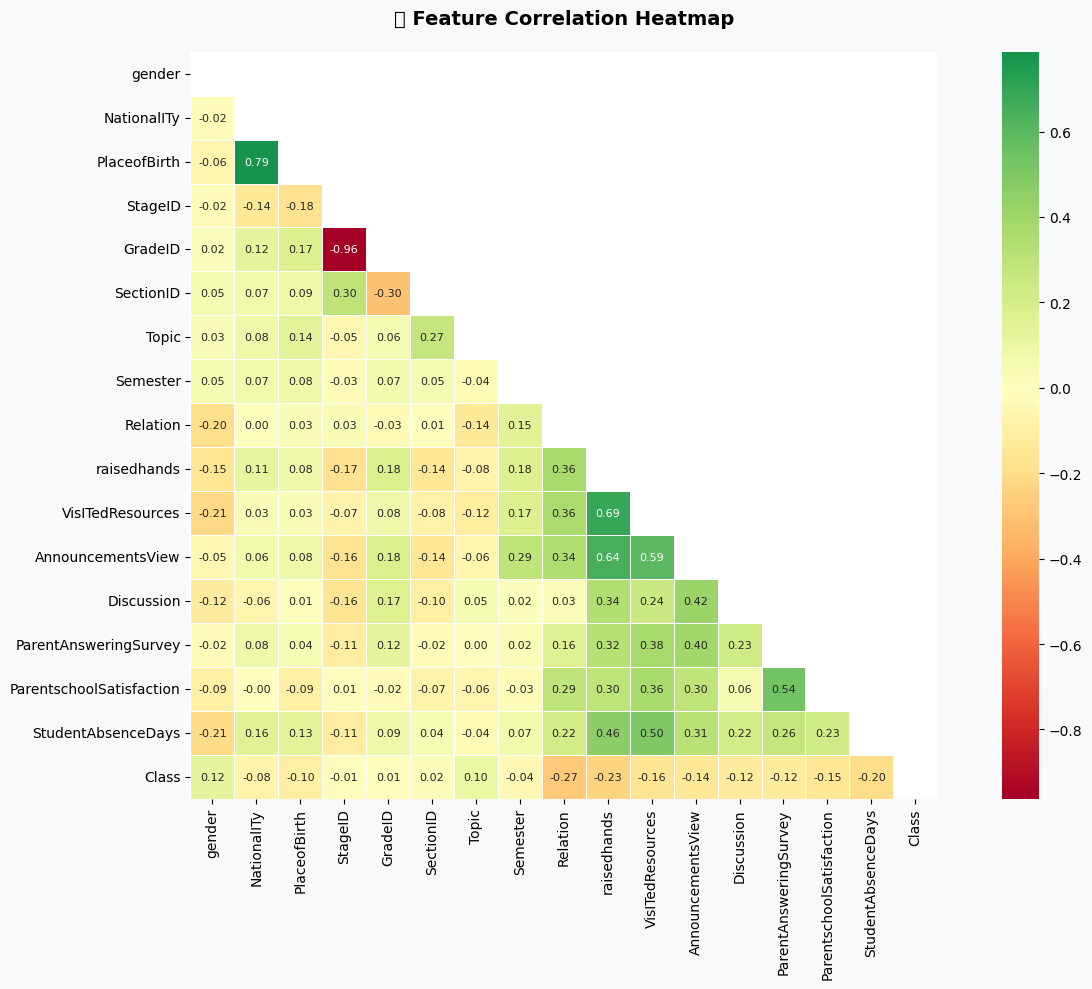

✅ Graph 4 saved: Correlation Heatmap


In [ ]:
# ── Graph 4: Correlation Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df_ml.corr()

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax, mask=mask,
            linewidths=0.5, annot_kws={'size': 8})
ax.set_title('🔥 Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('graph4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 4 saved: Correlation Heatmap")

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

print("⛏️  Running APRIORI Pattern Mining...")
print("=" * 60)

# Prepare transactions from key categorical features
# Discretize numeric features
df_pm = df_original.copy()
df_pm['raisedhands_cat'] = pd.cut(df_pm['raisedhands'], bins=3, labels=['Low_Hands', 'Med_Hands', 'High_Hands'])
df_pm['visited_cat']     = pd.cut(df_pm['VisITedResources'], bins=3, labels=['Low_Visit', 'Med_Visit', 'High_Visit'])
df_pm['announce_cat']    = pd.cut(df_pm['AnnouncementsView'], bins=3, labels=['Low_Ann', 'Med_Ann', 'High_Ann'])
df_pm['discussion_cat']  = pd.cut(df_pm['Discussion'], bins=3, labels=['Low_Disc', 'Med_Disc', 'High_Disc'])

# Build transaction list
transaction_cols = ['gender', 'StudentAbsenceDays', 'ParentAnsweringSurvey',
                    'ParentschoolSatisfaction', 'raisedhands_cat',
                    'visited_cat', 'announce_cat', 'discussion_cat', 'Class']

transactions = []
for _, row in df_pm[transaction_cols].dropna().iterrows():
    transaction = [f"{col}={val}" for col, val in zip(transaction_cols, row)]
    transactions.append(transaction)

print(f"📦 Total transactions prepared: {len(transactions)}")
print(f"   Sample transaction: {transactions[0]}")

# Apply TransactionEncoder
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)

# Run Apriori
frequent_itemsets_ap = apriori(df_te, min_support=0.15, use_colnames=True)
frequent_itemsets_ap['length'] = frequent_itemsets_ap['itemsets'].apply(len)

print(f"\n✅ Frequent Itemsets Found (Apriori): {len(frequent_itemsets_ap)}")
print("\n🏆 Top 10 Frequent Itemsets by Support:")
print(frequent_itemsets_ap.sort_values('support', ascending=False).head(10).to_string(index=False))

⛏️  Running APRIORI Pattern Mining...
📦 Total transactions prepared: 480
   Sample transaction: ['gender=M', 'StudentAbsenceDays=Under-7', 'ParentAnsweringSurvey=Yes', 'ParentschoolSatisfaction=Good', 'raisedhands_cat=Low_Hands', 'visited_cat=Low_Visit', 'announce_cat=Low_Ann', 'discussion_cat=Low_Disc', 'Class=M']

✅ Frequent Itemsets Found (Apriori): 325

🏆 Top 10 Frequent Itemsets by Support:
 support                                                   itemsets  length
0.635417                                                 (gender=M)       1
0.608333                            (ParentschoolSatisfaction=Good)       1
0.602083                               (StudentAbsenceDays=Under-7)       1
0.562500                                (ParentAnsweringSurvey=Yes)       1
0.493750                                     (announce_cat=Low_Ann)       1
0.493750                                   (visited_cat=High_Visit)       1
0.472917 (ParentAnsweringSurvey=Yes, ParentschoolSatisfaction=Good)  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Apriori Association Rules
rules_ap = association_rules(frequent_itemsets_ap, metric='confidence', min_threshold=0.6)
rules_ap = rules_ap.sort_values('confidence', ascending=False)

print(f"\n📜 Total Association Rules Generated (Apriori): {len(rules_ap)}")
print("\n🏆 Top 10 Rules by Confidence:")
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(rules_ap[display_cols].head(10).to_string(index=False))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


📜 Total Association Rules Generated (Apriori): 910

🏆 Top 10 Rules by Confidence:
                                                                                antecedents                  consequents  support  confidence     lift
                              (visited_cat=High_Visit, Class=H, raisedhands_cat=High_Hands) (StudentAbsenceDays=Under-7) 0.177083    0.988372 1.641587
                       (ParentschoolSatisfaction=Good, Class=H, raisedhands_cat=High_Hands) (StudentAbsenceDays=Under-7) 0.168750    0.987805 1.640645
                                                   (Class=H, ParentschoolSatisfaction=Good) (StudentAbsenceDays=Under-7) 0.241667    0.983051 1.632749
                                                      (Class=H, raisedhands_cat=High_Hands) (StudentAbsenceDays=Under-7) 0.206250    0.980198 1.628011
                        (ParentAnsweringSurvey=Yes, Class=H, ParentschoolSatisfaction=Good) (StudentAbsenceDays=Under-7) 0.202083    0.979798 1.627346
           

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

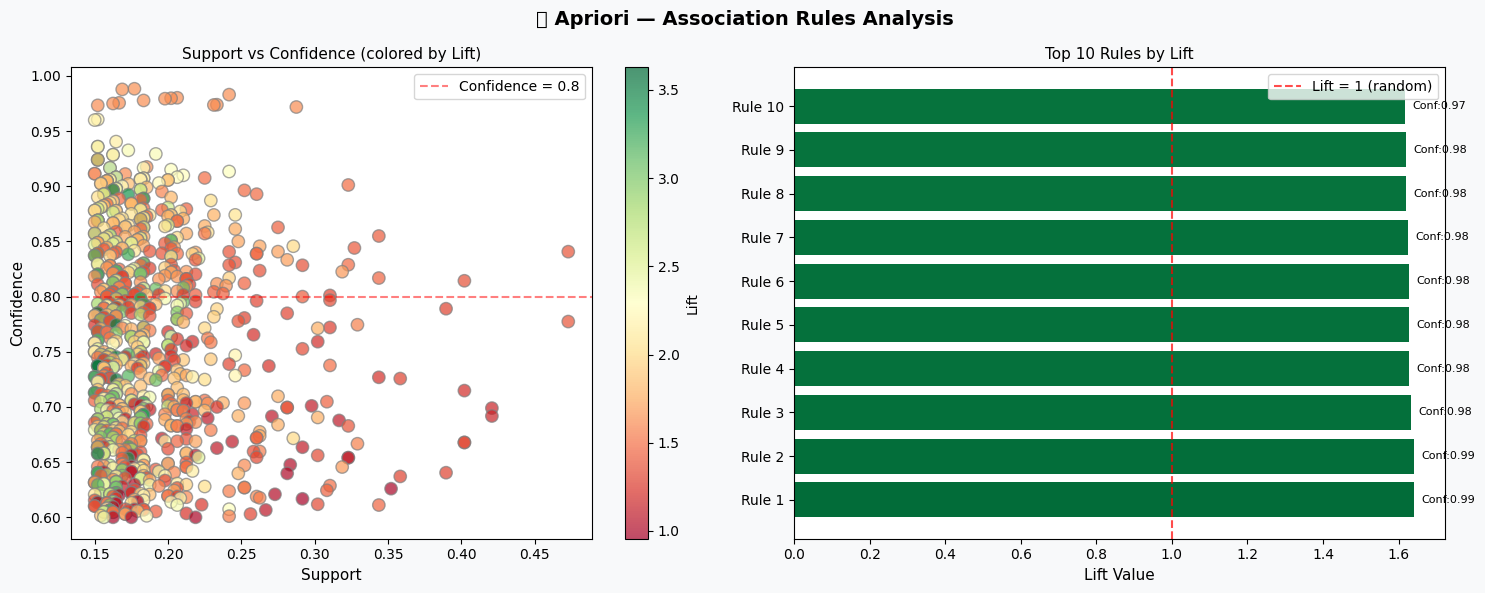

✅ Graph 5 saved: Apriori Association Rules


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── Graph 5: Apriori — Support vs Confidence Scatter
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('⛏️ Apriori — Association Rules Analysis', fontsize=14, fontweight='bold')

# Scatter: support vs confidence, colored by lift
sc = axes[0].scatter(rules_ap['support'], rules_ap['confidence'],
                     c=rules_ap['lift'], cmap='RdYlGn', s=80, alpha=0.7, edgecolors='grey')
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support', fontsize=11)
axes[0].set_ylabel('Confidence', fontsize=11)
axes[0].set_title('Support vs Confidence (colored by Lift)', fontsize=11)
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Confidence = 0.8')
axes[0].legend()

# Bar: Top 10 rules by lift
top_rules = rules_ap.head(10).copy()
rule_labels = [f"Rule {i+1}" for i in range(len(top_rules))]
bars = axes[1].barh(rule_labels, top_rules['lift'], color=plt.cm.RdYlGn(top_rules['confidence']))
axes[1].set_xlabel('Lift Value', fontsize=11)
axes[1].set_title('Top 10 Rules by Lift', fontsize=11)
axes[1].axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='Lift = 1 (random)')
axes[1].legend()
for bar, conf in zip(bars, top_rules['confidence']):
    axes[1].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f'Conf:{conf:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('graph5_apriori_rules.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 5 saved: Apriori Association Rules")

In [ ]:
from mlxtend.frequent_patterns import fpgrowth

print("🌳 Running FP-GROWTH Pattern Mining...")
print("=" * 60)

# Run FP-Growth on the same transaction matrix
frequent_itemsets_fp = fpgrowth(df_te, min_support=0.15, use_colnames=True)
frequent_itemsets_fp['length'] = frequent_itemsets_fp['itemsets'].apply(len)

print(f"✅ Frequent Itemsets Found (FP-Growth): {len(frequent_itemsets_fp)}")
print("\n🏆 Top 10 Frequent Itemsets by Support:")
print(frequent_itemsets_fp.sort_values('support', ascending=False).head(10).to_string(index=False))

# Generate Rules from FP-Growth
rules_fp = association_rules(frequent_itemsets_fp, metric='confidence', min_threshold=0.6)
rules_fp = rules_fp.sort_values('confidence', ascending=False)

print(f"\n📜 Total Association Rules (FP-Growth): {len(rules_fp)}")
print("\n🏆 Top 10 Rules by Confidence:")
print(rules_fp[display_cols].head(10).to_string(index=False))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

🌳 Running FP-GROWTH Pattern Mining...
✅ Frequent Itemsets Found (FP-Growth): 325

🏆 Top 10 Frequent Itemsets by Support:
 support                                                   itemsets  length
0.635417                                                 (gender=M)       1
0.608333                            (ParentschoolSatisfaction=Good)       1
0.602083                               (StudentAbsenceDays=Under-7)       1
0.562500                                (ParentAnsweringSurvey=Yes)       1
0.493750                                     (announce_cat=Low_Ann)       1
0.493750                                   (visited_cat=High_Visit)       1
0.472917 (ParentAnsweringSurvey=Yes, ParentschoolSatisfaction=Good)       2
0.460417                                  (discussion_cat=Low_Disc)       1
0.439583                                                  (Class=M)       1
0.437500                                 (ParentAnsweringSurvey=No)       1

📜 Total Association Rules (FP-Growth): 910

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

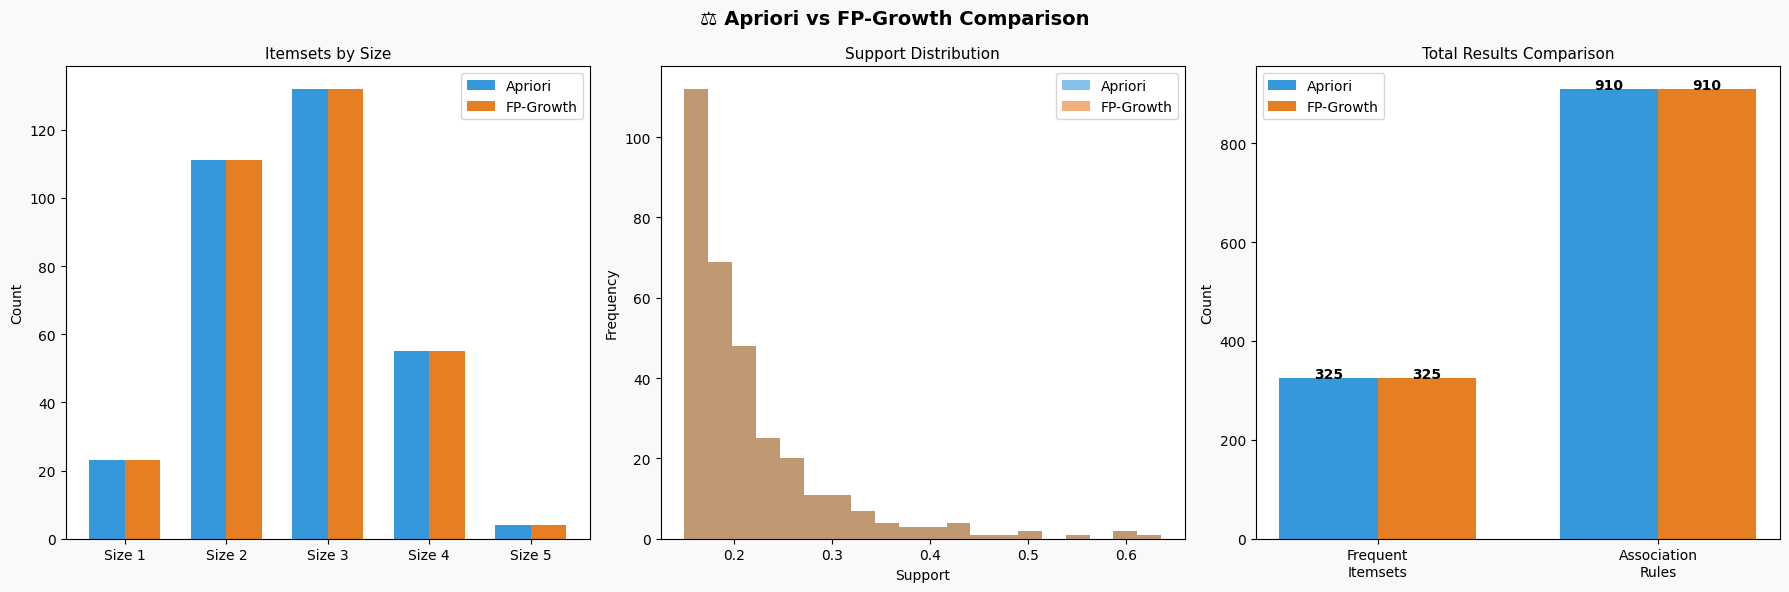

✅ Graph 6 saved: Apriori vs FP-Growth Comparison


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── Graph 6: Apriori vs FP-Growth Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('⚖️ Apriori vs FP-Growth Comparison', fontsize=14, fontweight='bold')

# 1) Number of frequent itemsets by length
ap_counts = frequent_itemsets_ap.groupby('length').size()
fp_counts = frequent_itemsets_fp.groupby('length').size()
all_lengths = sorted(set(ap_counts.index) | set(fp_counts.index))
x = np.arange(len(all_lengths))
w = 0.35
axes[0].bar(x - w/2, [ap_counts.get(l, 0) for l in all_lengths], w, label='Apriori', color='#3498db')
axes[0].bar(x + w/2, [fp_counts.get(l, 0) for l in all_lengths], w, label='FP-Growth', color='#e67e22')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Size {l}' for l in all_lengths])
axes[0].set_title('Itemsets by Size', fontsize=11)
axes[0].set_ylabel('Count')
axes[0].legend()

# 2) Support distribution comparison
axes[1].hist(frequent_itemsets_ap['support'], bins=20, alpha=0.6, label='Apriori', color='#3498db')
axes[1].hist(frequent_itemsets_fp['support'], bins=20, alpha=0.6, label='FP-Growth', color='#e67e22')
axes[1].set_title('Support Distribution', fontsize=11)
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# 3) Total summary comparison
categories = ['Frequent\nItemsets', 'Association\nRules']
ap_vals = [len(frequent_itemsets_ap), len(rules_ap)]
fp_vals = [len(frequent_itemsets_fp), len(rules_fp)]
x2 = np.arange(len(categories))
axes[2].bar(x2 - w/2, ap_vals, w, label='Apriori', color='#3498db')
axes[2].bar(x2 + w/2, fp_vals, w, label='FP-Growth', color='#e67e22')
for i, (a, f) in enumerate(zip(ap_vals, fp_vals)):
    axes[2].text(i - w/2, a + 0.5, str(a), ha='center', fontweight='bold')
    axes[2].text(i + w/2, f + 0.5, str(f), ha='center', fontweight='bold')
axes[2].set_xticks(x2)
axes[2].set_xticklabels(categories)
axes[2].set_title('Total Results Comparison', fontsize=11)
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('graph6_apriori_vs_fpgrowth.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 6 saved: Apriori vs FP-Growth Comparison")

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score)

# Feature selection
X = df_ml.drop('Class', axis=1)
y = df_ml['Class']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data Split Complete:")
print(f"   Training samples  : {X_train.shape[0]}")
print(f"   Testing samples   : {X_test.shape[0]}")
print(f"   Features used     : {X.shape[1]}")
print(f"   Classes           : {sorted(y.unique())} (0=H, 1=L, 2=M)")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Data Split Complete:
   Training samples  : 384
   Testing samples   : 96
   Features used     : 16
   Classes           : [np.int64(0), np.int64(1), np.int64(2)] (0=H, 1=L, 2=M)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import time

# Define all classifiers (AutoML pool)
models = {
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME'),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'SVM'                 : SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes'         : GaussianNB(),
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
}

print("🤖 AutoML: Training & Evaluating All Models...")
print("=" * 70)

results = []
trained_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    start = time.time()
    # Cross-validation
    cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    # Train on training set
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    train_time = time.time() - start

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')

    trained_models[name] = model
    results.append({
        'Model'          : name,
        'Test Accuracy'  : round(acc, 4),
        'CV Accuracy'    : round(cv_scores.mean(), 4),
        'CV Std'         : round(cv_scores.std(), 4),
        'F1 Score'       : round(f1, 4),
        'Training Time'  : round(train_time, 3),
    })
    print(f"  ✅ {name:<22} | Acc: {acc:.4f} | CV: {cv_scores.mean():.4f}±{cv_scores.std():.4f} | F1: {f1:.4f}")

results_df = pd.DataFrame(results).sort_values('CV Accuracy', ascending=False)
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print("\n" + "=" * 70)
print(f"🏆 BEST MODEL (AutoML Selected): {best_model_name}")
print(f"   CV Accuracy  : {results_df.iloc[0]['CV Accuracy']} ± {results_df.iloc[0]['CV Std']}")
print(f"   Test Accuracy: {results_df.iloc[0]['Test Accuracy']}")
print("=" * 70)
print("\n📊 Full Results Table:")
results_df

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

🤖 AutoML: Training & Evaluating All Models...
  ✅ Decision Tree          | Acc: 0.6250 | CV: 0.6458±0.0378 | F1: 0.6185


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  ✅ Random Forest          | Acc: 0.7917 | CV: 0.7812±0.0622 | F1: 0.7903


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  ✅ SVM                    | Acc: 0.6875 | CV: 0.7438±0.0641 | F1: 0.6884
  ✅ Naive Bayes            | Acc: 0.7292 | CV: 0.7167±0.0583 | F1: 0.7300
  ✅ Logistic Regression    | Acc: 0.7292 | CV: 0.7604±0.0480 | F1: 0.7281

🏆 BEST MODEL (AutoML Selected): Random Forest
   CV Accuracy  : 0.7812 ± 0.0622
   Test Accuracy: 0.7917

📊 Full Results Table:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future ver

,Model,Test Accuracy,CV Accuracy,CV Std,F1 Score,Training Time
1,Random Forest,0.7917,0.7812,0.0622,0.7903,0.991
7,Logistic Regression,0.7292,0.7604,0.0480,0.7281,0.181
5,SVM,0.6875,0.7438,0.0641,0.6884,0.235
2,Gradient Boosting,0.7292,0.7396,0.0785,0.7274,3.213
3,AdaBoost,0.7188,0.7396,0.0349,0.7201,1.414
6,Naive Bayes,0.7292,0.7167,0.0583,0.7300,0.017
4,KNN,0.7188,0.6979,0.0378,0.7186,0.069
0,Decision Tree,0.6250,0.6458,0.0378,0.6185,0.043


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

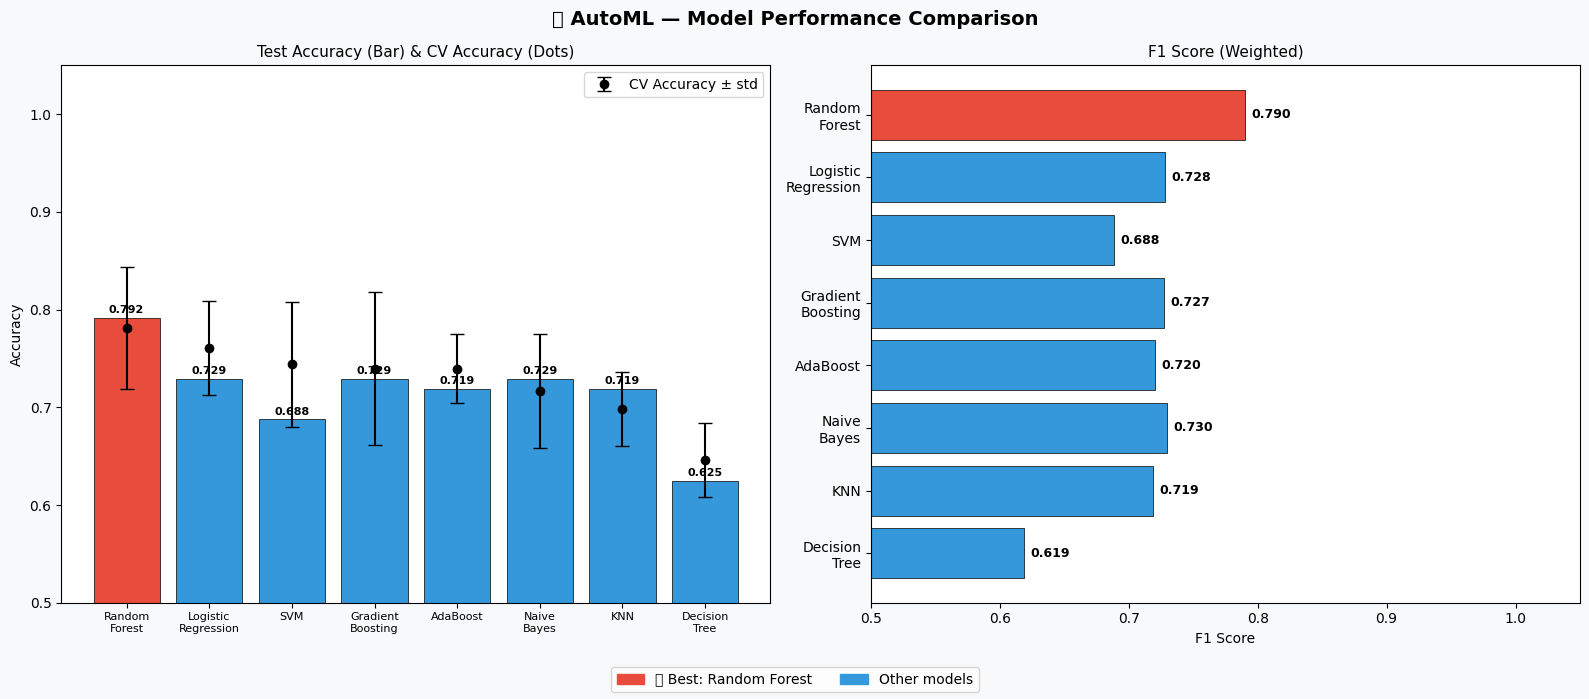

✅ Graph 7 saved: Model Comparison


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── Graph 7: Model Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('🤖 AutoML — Model Performance Comparison', fontsize=14, fontweight='bold')

model_names = results_df['Model'].tolist()
test_accs   = results_df['Test Accuracy'].tolist()
cv_accs     = results_df['CV Accuracy'].tolist()
cv_stds     = results_df['CV Std'].tolist()
f1_scores   = results_df['F1 Score'].tolist()

# Shorten names for display
short_names = [n.replace(' ', '\n') for n in model_names]
colors_bar  = ['#e74c3c' if n == best_model_name else '#3498db' for n in model_names]

# Bar chart — accuracy
bars = axes[0].bar(short_names, test_accs, color=colors_bar, edgecolor='black', linewidth=0.5)
axes[0].errorbar(range(len(model_names)), cv_accs, yerr=cv_stds,
                 fmt='o', color='black', capsize=5, label='CV Accuracy ± std')
axes[0].set_title('Test Accuracy (Bar) & CV Accuracy (Dots)', fontsize=11)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1.05)
axes[0].legend()
axes[0].tick_params(axis='x', labelsize=8)
for bar, acc in zip(bars, test_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', fontsize=8, fontweight='bold')

# Radar — F1 score
axes[1].barh(short_names[::-1], f1_scores[::-1], color=colors_bar[::-1],
             edgecolor='black', linewidth=0.5)
axes[1].set_title('F1 Score (Weighted)', fontsize=11)
axes[1].set_xlabel('F1 Score')
axes[1].set_xlim(0.5, 1.05)
for i, f1 in enumerate(f1_scores[::-1]):
    axes[1].text(f1 + 0.005, i, f'{f1:.3f}', va='center', fontsize=9, fontweight='bold')

# Add legend
red_patch  = mpatches.Patch(color='#e74c3c', label=f'🏆 Best: {best_model_name}')
blue_patch = mpatches.Patch(color='#3498db', label='Other models')
fig.legend(handles=[red_patch, blue_patch], loc='lower center', ncol=2, fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('graph7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 7 saved: Model Comparison")

In [ ]:
# Best model predictions
y_pred_best = best_model.predict(X_test)
class_labels = label_encoders['Class'].classes_

print(f"\n📋 Classification Report — {best_model_name}")
print("=" * 60)
print(classification_report(y_test, y_pred_best,
                             target_names=[f'Class {c}' for c in class_labels]))


📋 Classification Report — Random Forest
              precision    recall  f1-score   support

     Class H       0.78      0.72      0.75        29
     Class L       0.85      0.92      0.88        25
     Class M       0.76      0.76      0.76        42

    accuracy                           0.79        96
   macro avg       0.80      0.80      0.80        96
weighted avg       0.79      0.79      0.79        96



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

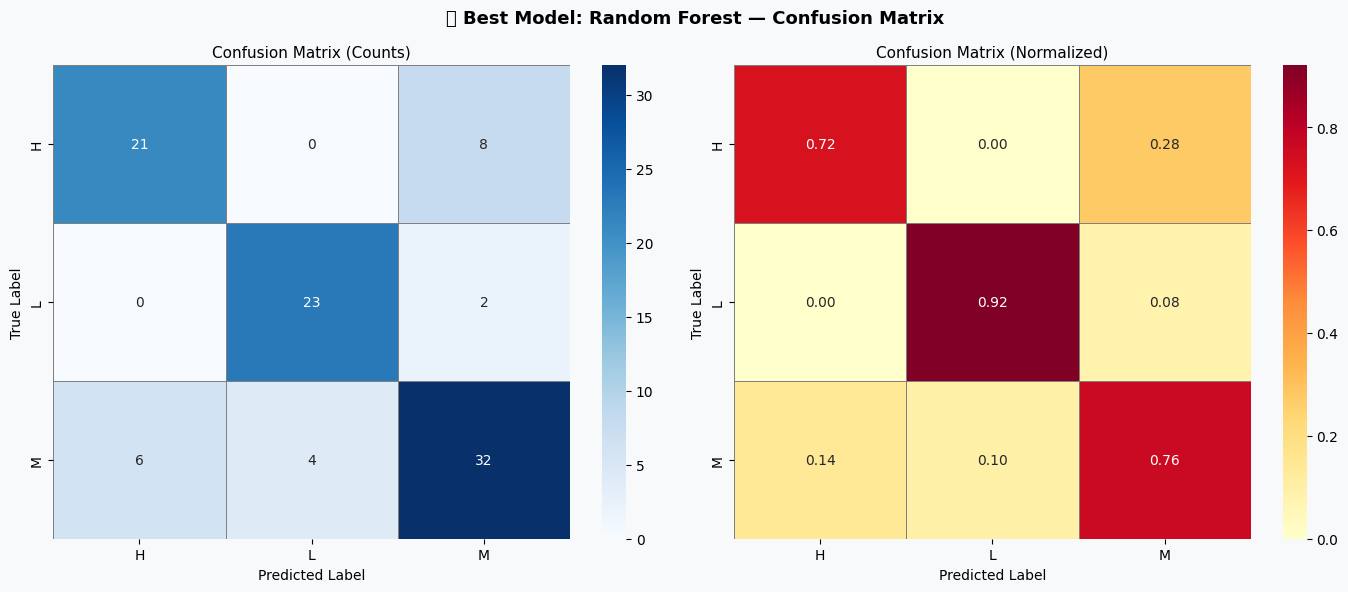

✅ Graph 8 saved: Confusion Matrix


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── Graph 8: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'🏆 Best Model: {best_model_name} — Confusion Matrix', fontsize=13, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.5, linecolor='grey')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=11)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.5, linecolor='grey')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=11)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('graph8_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 8 saved: Confusion Matrix")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

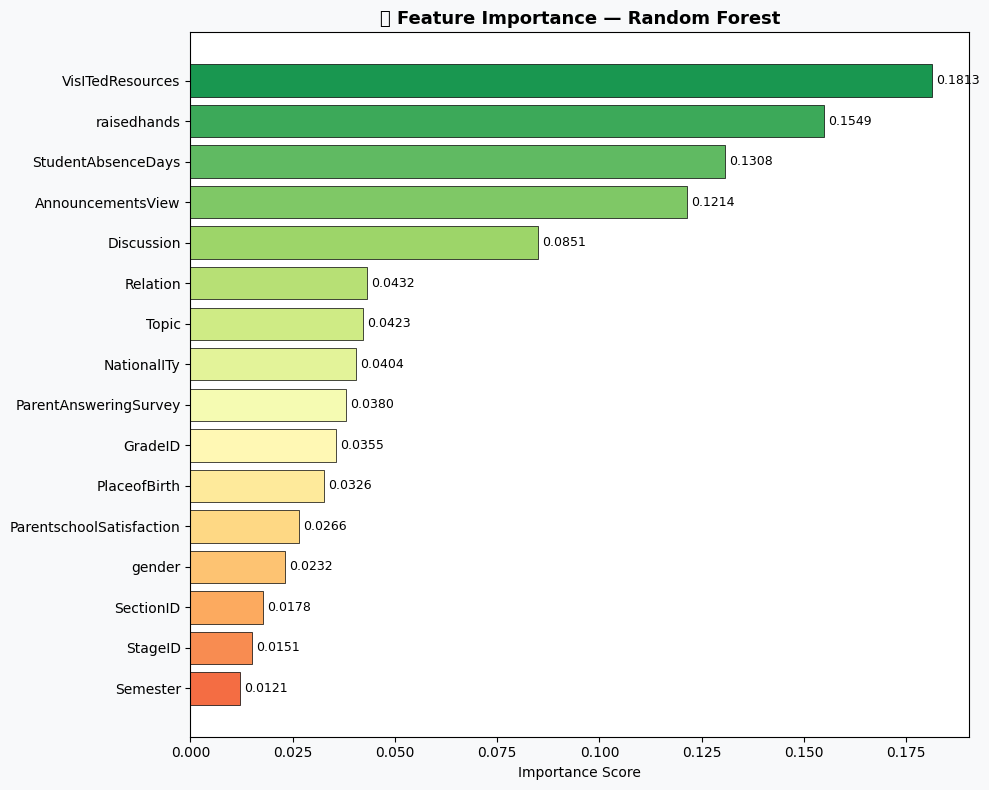

✅ Graph 9 saved: Feature Importance

🔑 Top 5 Most Important Features:
           Feature  Importance
  VisITedResources    0.181344
       raisedhands    0.154855
StudentAbsenceDays    0.130820
 AnnouncementsView    0.121369
        Discussion    0.085070


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── Graph 9: Feature Importance (if supported)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X.columns.tolist()
    feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp_df)))
    bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
                   color=colors_fi, edgecolor='black', linewidth=0.5)
    ax.set_title(f'🔑 Feature Importance — {best_model_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    for bar, imp in zip(bars, feat_imp_df['Importance']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{imp:.4f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('graph9_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Graph 9 saved: Feature Importance")
    print("\n🔑 Top 5 Most Important Features:")
    print(feat_imp_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))
else:
    print(f"ℹ️  {best_model_name} does not support feature_importances_")
    print("   Showing Logistic Regression coefficients instead...")
    lr_model = trained_models.get('Logistic Regression')
    if lr_model:
        coefs = np.abs(lr_model.coef_).mean(axis=0)
        feat_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefs})
        feat_df = feat_df.sort_values('Coefficient', ascending=True)
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.barh(feat_df['Feature'], feat_df['Coefficient'], color='#3498db')
        ax.set_title('Feature Coefficients (Logistic Regression)', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig('graph9_feature_importance.png', dpi=150, bbox_inches='tight')
        plt.show()

In [ ]:
# Predict on entire dataset
all_predictions = best_model.predict(X_scaled)
df_result = df_original.copy()
df_result['Predicted_Class_Encoded'] = all_predictions
df_result['Predicted_Performance'] = label_encoders['Class'].inverse_transform(all_predictions)

# Identify weak students (Low class)
weak_students = df_result[df_result['Predicted_Performance'] == 'L']

print("=" * 60)
print("        🚨 WEAK STUDENT ANALYSIS")
print("=" * 60)
print(f"Total Students    : {len(df_result)}")
print(f"Weak Students (L) : {len(weak_students)} ({len(weak_students)/len(df_result)*100:.1f}%)")

print("\n📊 Weak Students — Key Characteristics:")
print(f"   Avg Raised Hands     : {weak_students['raisedhands'].mean():.1f}")
print(f"   Avg Visited Resources: {weak_students['VisITedResources'].mean():.1f}")
print(f"   Avg Announcements    : {weak_students['AnnouncementsView'].mean():.1f}")
print(f"   Avg Discussion       : {weak_students['Discussion'].mean():.1f}")
print(f"   Absent > 7 days      : {(weak_students['StudentAbsenceDays'] == 'Above-7').sum()} students")

print("\n📋 Sample Weak Students (first 10):")
cols_show = ['gender', 'raisedhands', 'VisITedResources',
             'AnnouncementsView', 'Discussion', 'StudentAbsenceDays', 'Predicted_Performance']
weak_students[cols_show].head(10)

        🚨 WEAK STUDENT ANALYSIS
Total Students    : 480
Weak Students (L) : 129 (26.9%)

📊 Weak Students — Key Characteristics:
   Avg Raised Hands     : 15.9
   Avg Visited Resources: 17.9
   Avg Announcements    : 15.0
   Avg Discussion       : 31.0
   Absent > 7 days      : 118 students

📋 Sample Weak Students (first 10):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,gender,raisedhands,VisITedResources,AnnouncementsView,Discussion,StudentAbsenceDays,Predicted_Performance
2,M,10,7,0,30,Above-7,L
3,M,30,25,5,35,Above-7,L
6,M,35,12,0,17,Above-7,L
12,M,5,1,0,11,Above-7,L
13,M,20,14,12,19,Above-7,L
23,M,2,0,2,50,Above-7,L
24,M,0,2,3,70,Above-7,L
25,M,8,7,30,40,Above-7,L
27,M,25,15,12,33,Above-7,L
31,M,4,5,40,16,Above-7,L


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

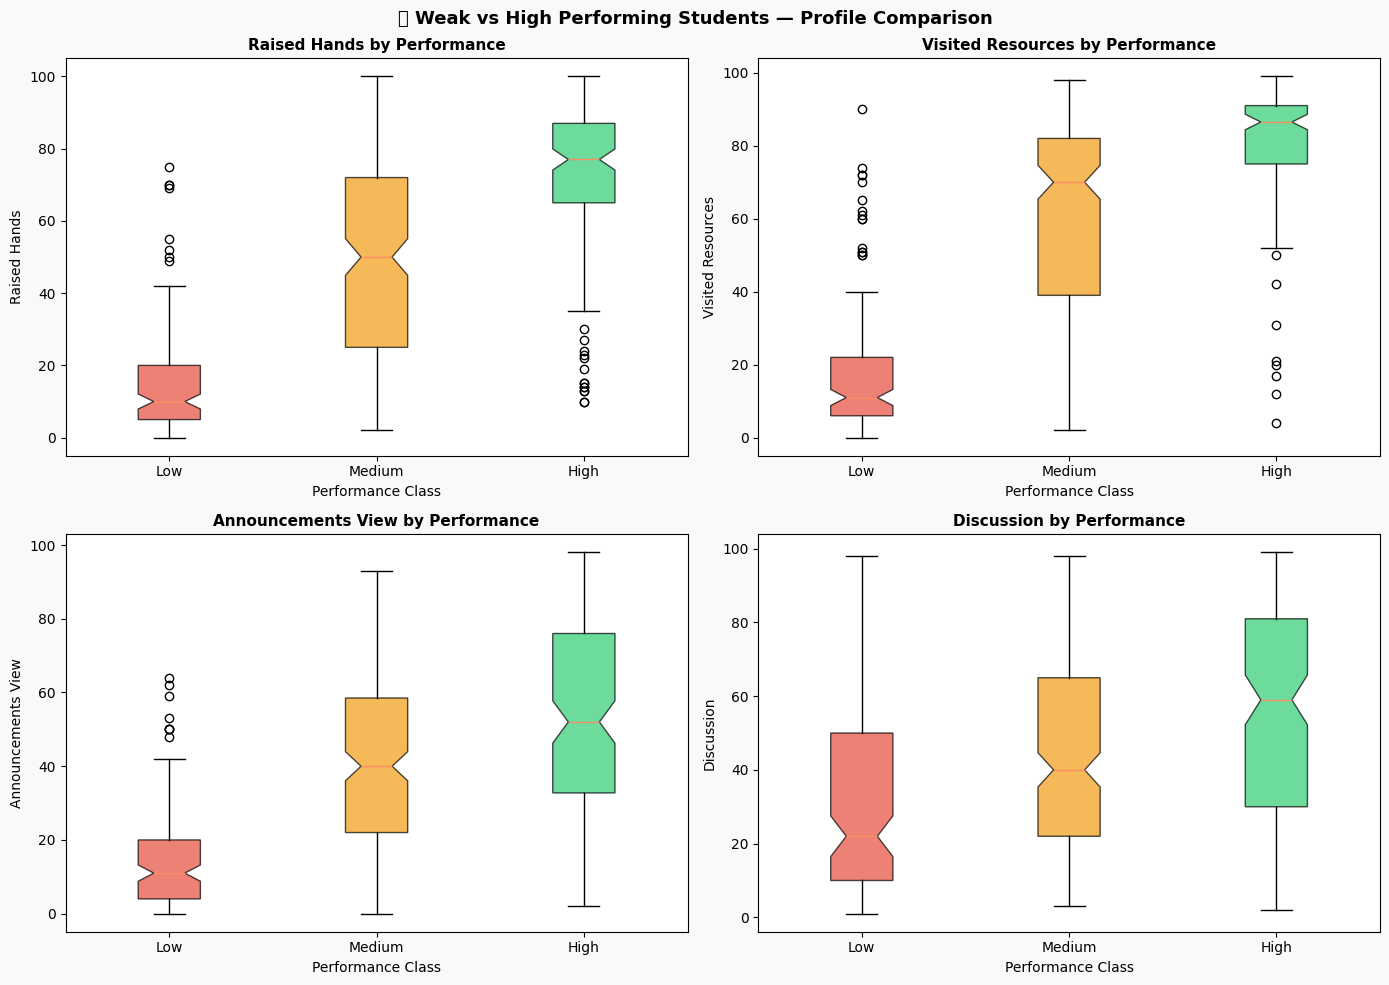

✅ Graph 10 saved: Weak vs Strong Student Analysis


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── Graph 10: Weak vs High Students Profile
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🚨 Weak vs High Performing Students — Profile Comparison', fontsize=13, fontweight='bold')

metrics = ['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']
metric_labels = ['Raised Hands', 'Visited Resources', 'Announcements View', 'Discussion']
axes = axes.flatten()

class_color_map = {'L': '#e74c3c', 'M': '#f39c12', 'H': '#2ecc71'}

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    data_dict = {}
    for cls in ['L', 'M', 'H']:
        data_dict[cls] = df_result[df_result['Predicted_Performance'] == cls][metric].values

    bp = axes[i].boxplot(list(data_dict.values()), labels=['Low', 'Medium', 'High'],
                         patch_artist=True, notch=True)
    for patch, (cls, _) in zip(bp['boxes'], data_dict.items()):
        patch.set_facecolor(class_color_map[cls])
        patch.set_alpha(0.7)

    axes[i].set_title(f'{label} by Performance', fontsize=11, fontweight='bold')
    axes[i].set_ylabel(label)
    axes[i].set_xlabel('Performance Class')

plt.tight_layout()
plt.savefig('graph10_weak_vs_strong_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 10 saved: Weak vs Strong Student Analysis")

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

print("="*60)
print("  🔮 NEW STUDENT PERFORMANCE PREDICTOR")
print("="*60)

# Build input widgets
gender_w    = widgets.Dropdown(options=['M', 'F'], description='Gender:')
absence_w   = widgets.Dropdown(options=['Under-7', 'Above-7'], description='Absence Days:')
hands_w     = widgets.IntSlider(min=0, max=100, value=50, description='Raised Hands:', style={'description_width':'140px'})
visited_w   = widgets.IntSlider(min=0, max=100, value=50, description='Visited Resources:', style={'description_width':'140px'})
announce_w  = widgets.IntSlider(min=0, max=100, value=50, description='Announcements:', style={'description_width':'140px'})
discuss_w   = widgets.IntSlider(min=0, max=100, value=50, description='Discussion:', style={'description_width':'140px'})
parent_w    = widgets.Dropdown(options=['Yes', 'No'], description='Parent Survey:')
satisfy_w   = widgets.Dropdown(options=['Good', 'Bad'], description='Parent Satisfied:')
semester_w  = widgets.Dropdown(options=['F', 'S'], description='Semester:')
relation_w  = widgets.Dropdown(options=['Father', 'Mum'], description='Parent Relation:')
predict_btn = widgets.Button(description='🔮 Predict Performance!', button_style='success',
                              layout=widgets.Layout(width='220px', height='40px'))
output_w    = widgets.Output()

def predict_student(btn):
    with output_w:
        clear_output()
        # Build a sample row matching df_original columns
        sample = df_original.iloc[0].copy()
        sample['gender'] = gender_w.value
        sample['StudentAbsenceDays'] = absence_w.value
        sample['raisedhands'] = hands_w.value
        sample['VisITedResources'] = visited_w.value
        sample['AnnouncementsView'] = announce_w.value
        sample['Discussion'] = discuss_w.value
        sample['ParentAnsweringSurvey'] = parent_w.value
        sample['ParentschoolSatisfaction'] = satisfy_w.value
        sample['Semester'] = semester_w.value
        sample['Relation'] = relation_w.value

        # Encode using trained label encoders
        sample_df = pd.DataFrame([sample])
        for col in categorical_cols:
            if col != 'Class' and col in sample_df.columns:
                le_col = label_encoders[col]
                val = sample_df[col].values[0]
                if val in le_col.classes_:
                    sample_df[col] = le_col.transform([val])[0]
                else:
                    sample_df[col] = 0
        sample_df['Class'] = 0

        X_sample = sample_df.drop('Class', axis=1).values
        X_sample_scaled = scaler.transform(X_sample)
        prediction = best_model.predict(X_sample_scaled)[0]
        predicted_class = label_encoders['Class'].inverse_transform([prediction])[0]

        class_meanings = {'H': ('High Performer 🏆', '#2ecc71', 'Excellent! Student is likely to perform well.'),
                          'M': ('Medium Performer 📚', '#f39c12', 'Average performance. Needs some improvement.'),
                          'L': ('Low Performer ⚠️',  '#e74c3c', 'At risk! Student needs immediate support.')}
        label, color, msg = class_meanings[predicted_class]

        print("\n" + "="*50)
        print(f"  🔮 PREDICTION RESULT")
        print("="*50)
        print(f"  Performance Class : {predicted_class}")
        print(f"  Status            : {label}")
        print(f"  Message           : {msg}")
        print(f"  Model Used        : {best_model_name}")
        print("="*50)

predict_btn.on_click(predict_student)

display(widgets.VBox([
    widgets.HBox([gender_w, semester_w, relation_w]),
    widgets.HBox([absence_w, parent_w, satisfy_w]),
    hands_w, visited_w, announce_w, discuss_w,
    predict_btn, output_w
]))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  🔮 NEW STUDENT PERFORMANCE PREDICTOR


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
print("=" * 70)
print("     📝 FINAL PROJECT SUMMARY REPORT")
print("     Python-Based AutoML Student Performance Prediction")
print("     UET GRW — Data Mining Project")
print("=" * 70)

print(f"""
1. DATASET
   Total Students    : {len(df_original)}
   Total Features    : {df_original.shape[1] - 1}
   Classes           : Low (L), Medium (M), High (H)

2. PATTERN MINING
   Algorithm 1       : Apriori
   Frequent Itemsets : {len(frequent_itemsets_ap)}
   Association Rules : {len(rules_ap)}

   Algorithm 2       : FP-Growth
   Frequent Itemsets : {len(frequent_itemsets_fp)}
   Association Rules : {len(rules_fp)}

3. AUTOML CLASSIFICATION
   Models Tested     : {len(models)}
   Best Model        : {best_model_name}
   Best CV Accuracy  : {results_df.iloc[0]['CV Accuracy']} ± {results_df.iloc[0]['CV Std']}
   Best Test Accuracy: {results_df.iloc[0]['Test Accuracy']}

4. WEAK STUDENTS IDENTIFIED
   Total Weak (L)    : {len(weak_students)} students ({len(weak_students)/len(df_result)*100:.1f}%)

5. GRAPHS GENERATED
   Graph 1  : Class Distribution
   Graph 2  : Feature Distributions by Class
   Graph 3  : Categorical Feature Analysis
   Graph 4  : Correlation Heatmap
   Graph 5  : Apriori Association Rules
   Graph 6  : Apriori vs FP-Growth Comparison
   Graph 7  : AutoML Model Comparison
   Graph 8  : Confusion Matrix
   Graph 9  : Feature Importance
   Graph 10 : Weak vs Strong Students Profile
""")
print("=" * 70)
print("✅ PROJECT COMPLETE!")
print("=" * 70)

     📝 FINAL PROJECT SUMMARY REPORT
     Python-Based AutoML Student Performance Prediction
     UET GRW — Data Mining Project

1. DATASET
   Total Students    : 480
   Total Features    : 16
   Classes           : Low (L), Medium (M), High (H)

2. PATTERN MINING
   Algorithm 1       : Apriori
   Frequent Itemsets : 325
   Association Rules : 910

   Algorithm 2       : FP-Growth
   Frequent Itemsets : 325
   Association Rules : 910

3. AUTOML CLASSIFICATION
   Models Tested     : 8
   Best Model        : Random Forest
   Best CV Accuracy  : 0.7812 ± 0.0622
   Best Test Accuracy: 0.7917

4. WEAK STUDENTS IDENTIFIED
   Total Weak (L)    : 129 students (26.9%)

5. GRAPHS GENERATED
   Graph 1  : Class Distribution
   Graph 2  : Feature Distributions by Class
   Graph 3  : Categorical Feature Analysis
   Graph 4  : Correlation Heatmap
   Graph 5  : Apriori Association Rules
   Graph 6  : Apriori vs FP-Growth Comparison
   Graph 7  : AutoML Model Comparison
   Graph 8  : Confusion Matrix
  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag